주말에 아기를 재우고 웹서핑을 하다가, 재미있는 글을 발견했습니다.

Grantham, Mayo, Van Otterloo & Co. LLC (GMO) 라는 미국 자산운용사에서 나온 2023년 리포트인데, ([리포트 보기 링크](https://www.gmo.com/globalassets/articles/viewpoints/2023/gmo_after-a-timeout---back-to-the-meat-grinder_1-23.pdf))

중간에 재미있는 내용이 있습니다.

> The important fact here – see Exhibit 1 – is
that for 7 months of the Presidential Cycle, from October 1st of the second year (this cycle,
2022) through April 30th of the third year (2023), the returns, since 1932, equal those of the
remaining 41 months of the cycle! This has a less than one-in-a-million probability of occurring
by chance, pretty remarkably, and it has been about as powerful in the last 45 years as the
previous 45 years. 

미국 대통령 선거주기에서 `2년차 10월~3년차 4월`의 수익이 유난히 높았다는 주장입니다. 
- 미국 대통령 임기 2년 차 10월 1일부터 임기 3년 차 4월 30일까지 총 7개월
- 1932년 이후 이 7개월의 누적 수익이 나머지 41개월 전체 수익과 비슷함

어? 정말 그런가? 궁금해집니다. 역사가 50년이 넘은 GMO에서 근거 없는 이야기를 했을리는 없겠지만 그래도 직접 확인해보고 싶어집니다.

> **먼저 결론.**
> - 공개 S&P 500, NASDAQ 100 가격지수로 계산했을 때 이 7개월의 지수 상승률은 같은 선거주기 안의 다른 7개월보다 평균적으로 높았다.
> - 계절을 맞춘 추가 비교에서도 차이는 남았다. 다만 이는 과거 자료의 관찰이지, 다음 선거주기에 대한 예측은 아니다.

## 1. 출발점

- GMO는 4년 대통령 선거주기에서 `2년차 10월 1일~3년차 4월 30일`의 7개월이 강했다고 주장했다.
- 여기서 중요한 규칙이 하나 있다. **재선되면 다시 1년차**다. 예를 들어 `2017~2020` 다음에는, 같은 대통령이어도 `2021~2024`를 새 주기로 센다.
- GMO의 원래 그림은 Global Financial Data의 S&P 500 실질 총수익률을 썼다.
- 여기서는 누구나 다시 받을 수 있는 Yahoo `^GSPC` **명목 가격지수**를 사용했다.
    - 배당과 물가 조정까지 같은 결과를 복제한 것은 아니다. 대신 공개 데이터에서도 같은 방향의 차이가 보이는지 확인하는 데 초점을 맞췄다.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# 정적 HTML 변환에서도 Plotly 차트가 보이도록 노트북용 HTML 출력을 사용합니다.
pio.renderers.default = 'notebook_connected'

ROOT = Path.cwd()
if not (ROOT / 'data').is_dir():
    ROOT = ROOT.parent
INDEX_PATH = ROOT / 'data' / 'indices' / 'us_price_indices_daily.csv'
ANALYSIS_END_DATE = pd.Timestamp('2026-08-01')

COLORS = {'target': '#FFB000', 'other': '#0057B8', 'difference': '#007A4D', 'negative': '#D7263D', 'ink': '#101820', 'grid': '#B8C2CC', 'paper': '#FFFFFF', 'plot': '#F2F5F7'}
def high_contrast(fig, height=480):
    fig.update_layout(
        template=None, paper_bgcolor=COLORS['paper'], plot_bgcolor=COLORS['plot'], height=height,
        font=dict(color=COLORS['ink'], size=14), title=dict(x=0.02, xanchor='left', font=dict(size=20, color=COLORS['ink'])),
        legend=dict(bgcolor='rgba(255,255,255,0.92)', bordercolor=COLORS['ink'], borderwidth=1),
        margin=dict(l=70, r=35, t=75, b=65), hoverlabel=dict(bgcolor=COLORS['ink'], font=dict(color='white', size=13)),
    )
    fig.update_xaxes(showline=True, linecolor=COLORS['ink'], linewidth=1.5, gridcolor=COLORS['grid'], zeroline=False)
    fig.update_yaxes(showline=True, linecolor=COLORS['ink'], linewidth=1.5, gridcolor=COLORS['grid'], zerolinecolor=COLORS['ink'])
    return fig


## 2. 무엇을 비교하나

- 한 선거주기는 48개월이며, **가설 구간**은 그중 7개월.
- 같은 주기 안에서는 7개월짜리 월초 시작 구간을 42개 만들 수 있고, 가설 구간은 그중 하나. 나머지 41개는 서로 많이 겹침.
- 예를 들어 `2022년 10월~2023년 4월`과 `2022년 11월~2023년 5월`은 6개월을 공유한다. 따라서 41개를 서로 완전히 다른 41개 실험 결과처럼 취급하면 안 됩니다.


In [2]:
prices = pd.read_csv(INDEX_PATH, parse_dates=['date'])
prices = prices.loc[prices['index_symbol'].eq('^GSPC') & prices['date'].le(ANALYSIS_END_DATE), ['date', 'close']].dropna().sort_values('date').reset_index(drop=True)
dates = prices['date'].to_numpy(dtype='datetime64[ns]')
closes = prices['close'].to_numpy(dtype=float)

def price_return(start, end_exclusive):
    left = np.searchsorted(dates, np.datetime64(start), side='left')
    right = np.searchsorted(dates, np.datetime64(end_exclusive), side='left')
    if right >= len(closes) or right <= left:
        return None
    return closes[right] / closes[left] - 1

cycle_rows, monthly_rows, window_rows = [], [], []
last_available = prices['date'].iloc[-1] + pd.Timedelta(days=1)
for cycle_start_year in range(1933, last_available.year + 1, 4):
    cycle_end = pd.Timestamp(cycle_start_year + 4, 1, 1)
    if cycle_end > last_available:
        break
    for month_offset in range(48):
        start = pd.Timestamp(cycle_start_year + month_offset // 12, month_offset % 12 + 1, 1)
        end = start + pd.DateOffset(months=1)
        monthly_rows.append({'cycle_start_year': cycle_start_year, 'month_offset': month_offset, 'return': price_return(start, end), 'is_target_month': 21 <= month_offset < 28})
    for start_offset in range(42):
        start = pd.Timestamp(cycle_start_year + start_offset // 12, start_offset % 12 + 1, 1)
        end = start + pd.DateOffset(months=7)
        window_rows.append({'cycle_start_year': cycle_start_year, 'start_offset': start_offset, 'start': start, 'end_exclusive': end, 'return': price_return(start, end), 'is_target_window': start_offset == 21})

monthly = pd.DataFrame(monthly_rows)
windows = pd.DataFrame(window_rows)
window_matrix = windows.pivot(index='cycle_start_year', columns='start_offset', values='return').sort_index()
target_return = window_matrix[21]
other_window_mean = (window_matrix.sum(axis=1) - target_return) / 41
cycle_effect = target_return - other_window_mean
cycle_table = pd.DataFrame({'대상_7개월_수익률': target_return, '기타_7개월_평균수익률': other_window_mean, '초과수익': cycle_effect}).reset_index()
print(f'완결 선거주기: {len(cycle_table)}개 ({cycle_table.cycle_start_year.min()}~{cycle_table.cycle_start_year.max()} 시작)')


완결 선거주기: 23개 (1933~2021 시작)


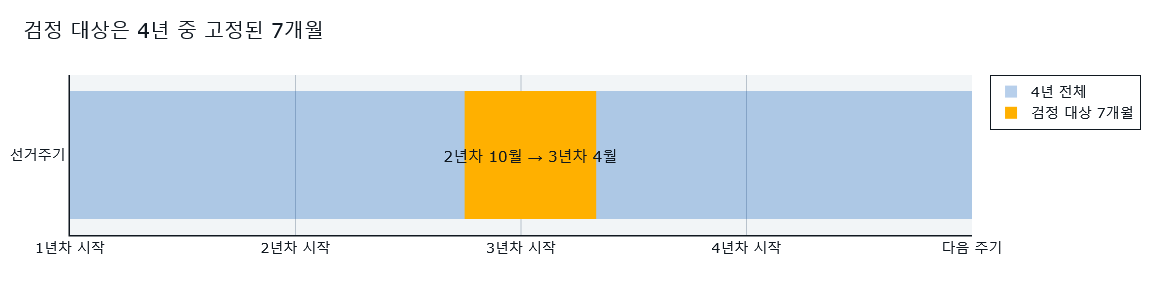

In [9]:
timeline = go.Figure()
timeline.add_trace(go.Bar(x=[48], y=['선거주기'], base=[0], orientation='h', marker_color=COLORS['other'], opacity=0.28, name='4년 전체'))
timeline.add_trace(go.Bar(x=[7], y=['선거주기'], base=[21], orientation='h', marker_color=COLORS['target'], name='가설 구간: 7개월'))
timeline.add_annotation(x=24.5, y='선거주기', text='2년차 10월 → 3년차 4월', showarrow=False, font=dict(color=COLORS['ink'], size=15))
timeline.update_xaxes(range=[0, 48], tickvals=[0, 12, 24, 36, 48], ticktext=['1년차 시작', '2년차 시작', '3년차 시작', '4년차 시작', '다음 주기'])
timeline.update_yaxes(showgrid=False)
timeline.update_layout(title='가설 구간은 4년 중 고정된 7개월', barmode='overlay', showlegend=True)
high_contrast(timeline, 300).show()


## 3. 먼저, 그림이 말하는 것

GMO의 원래 그림은 가설 구간 7개월과 나머지 41개월의 월별 성과를 연율로 바꿔 비교한다. 아래는 그 방식을 공개 가격지수에 적용한 결과다. 연율은 ‘매달 같은 속도로 움직였다고 가정하면 1년에는 몇 %인가’를 보여 주는 표현이다.


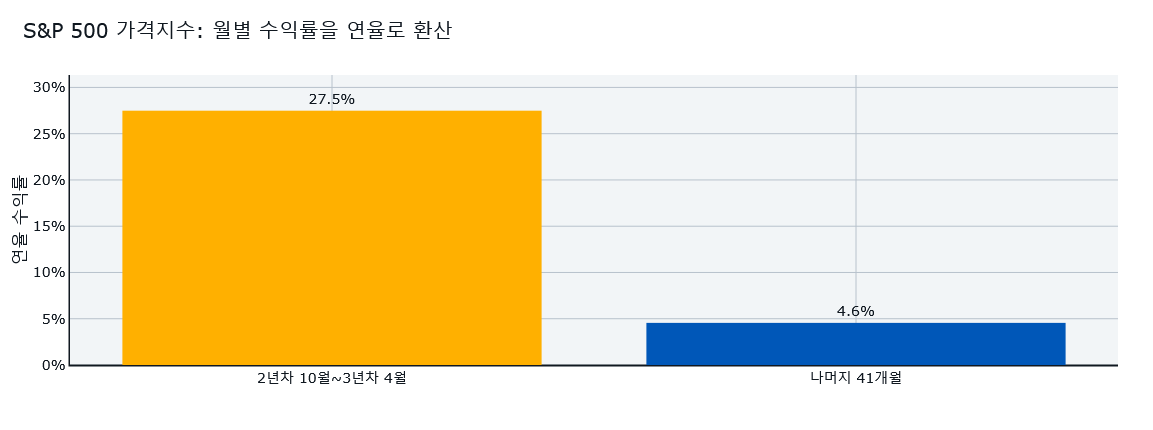

,측정값,평균 상관계수
0,한 달 수익률의 바로 다음 달 상관,0.004826
1,겹치는 7개월 구간의 바로 다음 구간 상관,0.816555


In [4]:
def annualized_from_monthly(values):
    return np.expm1(np.log1p(values).mean() * 12)

target_month_returns = monthly.loc[monthly['is_target_month'], 'return']
other_month_returns = monthly.loc[~monthly['is_target_month'], 'return']
annualized_target = annualized_from_monthly(target_month_returns)
annualized_other = annualized_from_monthly(other_month_returns)

fig = go.Figure(go.Bar(
    x=['2년차 10월~3년차 4월', '나머지 41개월'], y=[annualized_target * 100, annualized_other * 100],
    marker_color=[COLORS['target'], COLORS['other']], text=[f'{annualized_target:.1%}', f'{annualized_other:.1%}'], textposition='outside',
))
fig.update_layout(title='S&P 500 가격지수: 월별 수익률을 연율로 환산', yaxis_title='연율 수익률', showlegend=False)
fig.update_yaxes(ticksuffix='%')
high_contrast(fig, 430).show()
pd.DataFrame({'구간': ['가설 구간 7개월', '나머지 41개월'], '연율 수익률': [annualized_target, annualized_other]})

# 바로 이웃한 7개월 구간은 6개월을 공유하므로 수익률도 함께 움직이기 쉽습니다.
window_autocorrelation = windows.groupby('cycle_start_year')['return'].apply(lambda x: x.autocorr(lag=1)).mean()
monthly_autocorrelation = monthly.groupby('cycle_start_year')['return'].apply(lambda x: x.autocorr(lag=1)).mean()
dependence_metrics = pd.DataFrame({
    '측정값': ['한 달 수익률의 바로 다음 달 상관', '겹치는 7개월 구간의 바로 다음 구간 상관'],
    '평균 상관계수': [monthly_autocorrelation, window_autocorrelation],
})
dependence_metrics


## 4. 자기상관·겹침: 왜 보정이 필요한가

**맞습니다. 문제의 핵심은 자기상관과 겹침입니다.** ‘자기상관’은 오늘의 값과 바로 전 값이 서로 관계가 있는 현상입니다. 가격 수준은 원래 매우 강하게 이어지고, 수익률도 시장 상황이 이어질 수 있습니다. 더 직접적인 문제는 7개월 구간의 기계적인 겹침입니다. 예를 들어 `10월~4월`과 `11월~5월`은 6개월을 같이 쓰므로, 두 수익률은 독립적인 두 번의 실험이 아닙니다. 바로 위 표에서 한 달 수익률보다 ‘겹치는 7개월 구간’의 이웃 상관이 훨씬 크게 나오는 이유입니다.

그래서 41개 비교 구간을 표본 41개로 세면 안 됩니다. **선거주기 하나를 하나의 묶음(블록)** 으로 봅니다. 매 주기마다 ‘가설 구간 수익률 − 그 주기의 기타 41개 평균’을 하나만 계산합니다. 이 23개의 차이가 우리의 실제 비교 단위입니다.

이 설계는 1930년대의 시장 환경과 2010년대의 시장 환경처럼 서로 다른 시대를 같은 주기 안에서 비교하게 해 줍니다.


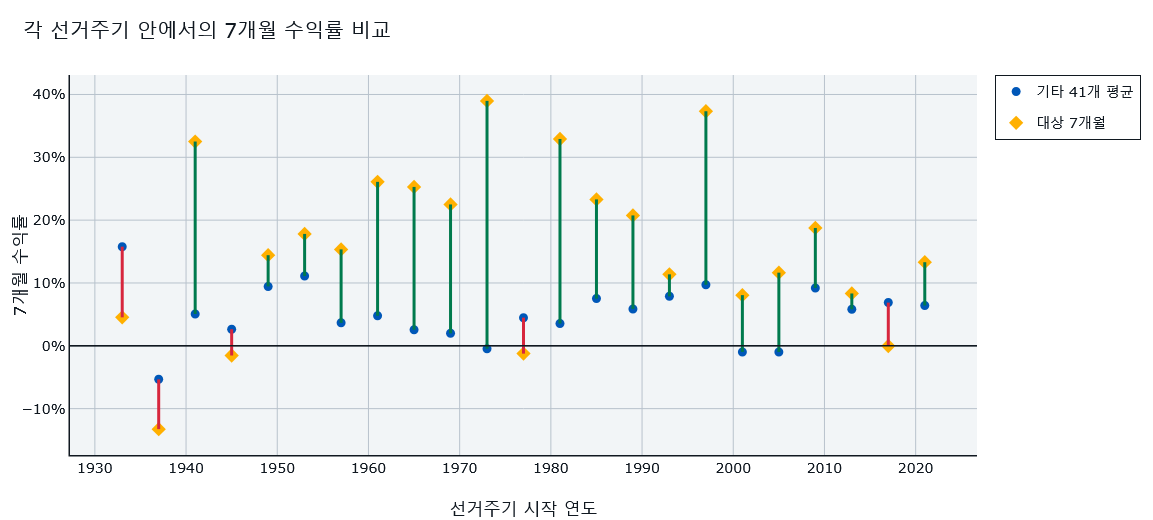

In [5]:
plot_data = cycle_table.sort_values('cycle_start_year')
fig = go.Figure()
for _, row in plot_data.iterrows():
    is_first_cycle = bool(row['cycle_start_year'] == plot_data['cycle_start_year'].min())
    color = COLORS['difference'] if row['초과수익'] >= 0 else COLORS['negative']
    fig.add_shape(type='line', x0=row['cycle_start_year'], x1=row['cycle_start_year'], y0=row['기타_7개월_평균수익률'] * 100, y1=row['대상_7개월_수익률'] * 100, line=dict(color=color, width=3))
    fig.add_trace(go.Scatter(x=[row['cycle_start_year']], y=[row['기타_7개월_평균수익률'] * 100], mode='markers', marker=dict(size=9, color=COLORS['other'], symbol='circle'), name='기타 41개 평균', legendgroup='other', showlegend=is_first_cycle, hovertemplate='%{x} 시작 주기<br>기타 평균: %{y:.1f}%<extra></extra>'))
    fig.add_trace(go.Scatter(x=[row['cycle_start_year']], y=[row['대상_7개월_수익률'] * 100], mode='markers', marker=dict(size=11, color=COLORS['target'], symbol='diamond'), name='가설 구간', legendgroup='target', showlegend=is_first_cycle, hovertemplate='%{x} 시작 주기<br>가설 구간: %{y:.1f}%<extra></extra>'))
fig.add_hline(y=0, line_color=COLORS['ink'], line_width=1.5)
fig.update_layout(title='각 선거주기 안에서의 7개월 수익률 비교', xaxis_title='선거주기 시작 연도', yaxis_title='7개월 수익률', hovermode='x unified')
fig.update_yaxes(ticksuffix='%')
high_contrast(fig, 520).show()


## 5. 선거주기 단위 랜덤화 검정

질문은 ‘2년차 10월이 특별하지 않다면, 42개 시작점 중 무작위로 하나를 골라도 지금처럼 큰 차이가 자주 나올까?’입니다.

각 주기에서 가설 구간 표시를 42개 시작점 중 임의의 한 곳으로 옮깁니다. 그 상태에서 23개 주기의 평균 초과수익을 계산합니다. 이를 100,000번 반복하면, **우연만 있을 때 나올 수 있는 평균 초과수익의 분포**가 만들어집니다. 실제 값이 그 분포의 아주 오른쪽에 있으면 이 시작월이 드물게 강하다는 뜻입니다.


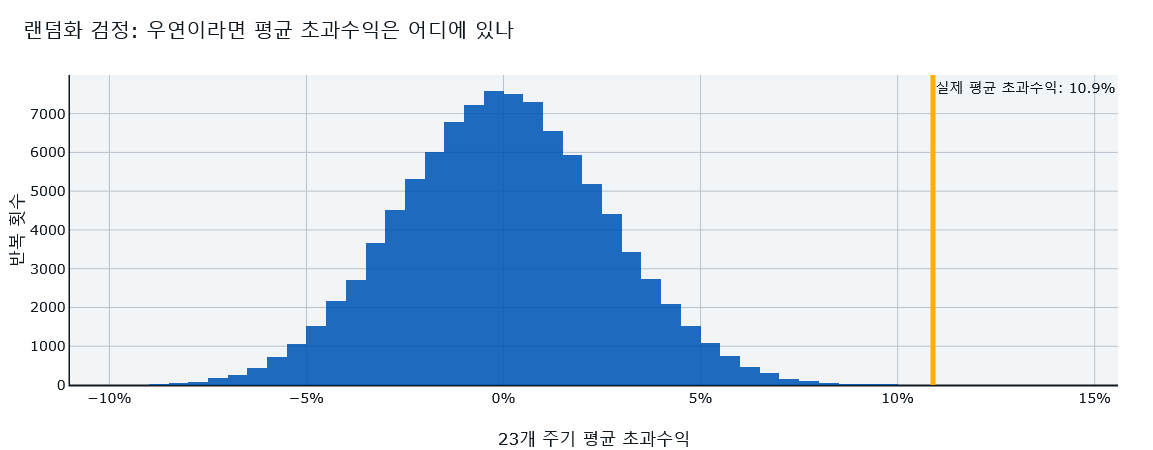

단측 랜덤화 p값: 0.000060


In [6]:
RNG = np.random.default_rng(20260802)
DRAWS = 100_000
matrix = window_matrix.to_numpy()
observed_effect = cycle_effect.mean()
random_start_positions = RNG.integers(0, 42, size=(DRAWS, len(matrix)))
selected = matrix[np.arange(len(matrix))[None, :], random_start_positions]
all_window_sums = matrix.sum(axis=1)
permutation_effects = (selected - (all_window_sums[None, :] - selected) / 41).mean(axis=1)
one_sided_p = (np.count_nonzero(permutation_effects >= observed_effect) + 1) / (DRAWS + 1)

fig = go.Figure(go.Histogram(x=permutation_effects * 100, nbinsx=70, marker_color=COLORS['other'], opacity=0.88, name='무작위로 고른 구간'))
fig.add_vline(x=observed_effect * 100, line_color=COLORS['target'], line_width=5, annotation_text=f'실제 평균 초과수익: {observed_effect:.1%}', annotation_position='top right')
fig.update_layout(title='랜덤화 검정: 우연이라면 평균 초과수익은 어디에 있나', xaxis_title='23개 주기 평균 초과수익', yaxis_title='반복 횟수', showlegend=False)
fig.update_xaxes(ticksuffix='%')
high_contrast(fig, 450).show()
print(f'단측 랜덤화 p값: {one_sided_p:.6f}')


## 6. 선거주기 블록 부트스트랩

랜덤화 검정은 ‘우연처럼 보이는가’를 답합니다. 부트스트랩은 ‘평균 초과수익이 정확히 얼마쯤일까’를 답합니다.

23개 선거주기를 카드 23장이라고 생각합니다. 카드를 한 장씩이 아니라 **선거주기 전체**로 다시 뽑습니다. 같은 카드가 여러 번 뽑혀도 됩니다. 매번 평균 초과수익을 계산해 100,000개의 평균을 만들고, 가운데 95% 범위를 신뢰구간으로 사용합니다. 7개월 구간들의 겹침은 각 카드 안에 그대로 남아 있습니다.


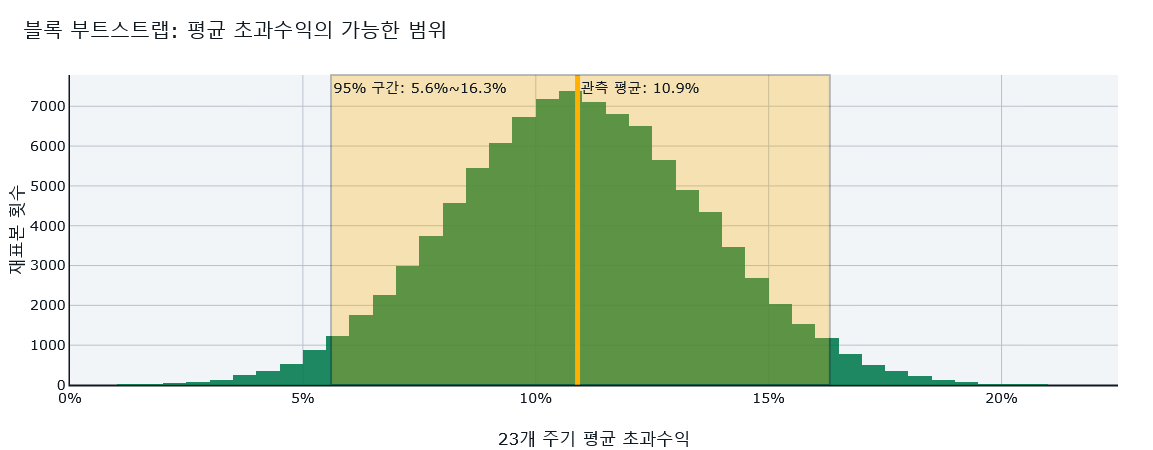

In [7]:
bootstrap_indices = RNG.integers(0, len(cycle_effect), size=(DRAWS, len(cycle_effect)))
bootstrap_means = cycle_effect.to_numpy()[bootstrap_indices].mean(axis=1)
ci_low, ci_high = np.quantile(bootstrap_means, [0.025, 0.975])

fig = go.Figure(go.Histogram(x=bootstrap_means * 100, nbinsx=70, marker_color=COLORS['difference'], opacity=0.88, name='재표본 평균'))
fig.add_vline(x=observed_effect * 100, line_color=COLORS['target'], line_width=5, annotation_text=f'관측 평균: {observed_effect:.1%}', annotation_position='top right')
fig.add_vrect(x0=ci_low * 100, x1=ci_high * 100, fillcolor=COLORS['target'], opacity=0.28, line_width=2, line_color=COLORS['ink'], annotation_text=f'95% 구간: {ci_low:.1%}~{ci_high:.1%}', annotation_position='top left')
fig.update_layout(title='블록 부트스트랩: 평균 초과수익의 가능한 범위', xaxis_title='23개 주기 평균 초과수익', yaxis_title='재표본 횟수', showlegend=False)
fig.update_xaxes(ticksuffix='%')
high_contrast(fig, 450).show()


## 7. 결과를 어떻게 읽을까

이 결과는 ‘가설 구간 7개월이 역사적으로 같은 선거주기의 다른 7개월보다 강했다’는 증거를 보여줄 수 있습니다. 하지만 미래에 반드시 상승한다는 보장은 아닙니다. 또한 이 노트북은 GMO가 이미 공개한 가설을 재현하는 것이므로, ‘이 규칙이 처음 발견될 때 데이터 탐색이 전혀 없었다’까지 증명하지는 않습니다.

두 가지 한계도 기억해야 합니다. 첫째, 이 랜덤화 검정은 42개 시작월을 같은 기준으로 비교하므로, ‘`10월~4월`’이라는 **계절 효과**와 ‘선거주기 2년차→3년차’ 효과를 완전히 분리하지는 못합니다. 선거주기만의 효과를 따로 보려면 다른 선거연도의 같은 `10월~4월`과 추가 비교해야 합니다. 둘째, 블록 부트스트랩은 겹침 문제를 보존하지만, 대공황·전쟁처럼 여러 주기에 걸친 큰 경제 환경이 완전히 독립이라고 만들어 주지는 않습니다. 따라서 결과는 강한 역사적 패턴이지, 확정된 법칙은 아닙니다.

핵심 보고 숫자는 평균 초과수익, 95% 신뢰구간, 랜덤화 p값, 그리고 가설 구간이 주기 내 평균을 이긴 비율입니다.


In [8]:
report = pd.DataFrame({
    '항목': ['완결 선거주기 수', '가설 구간 7개월 평균 수익률', '같은 주기 내 기타 7개월 평균', '평균 초과수익', '평균 초과수익 95% 구간', '가설 구간이 기타 평균을 이긴 주기 비율', '단측 랜덤화 p값'],
    '결과': [
        len(cycle_effect), f'{target_return.mean():.2%}', f'{other_window_mean.mean():.2%}', f'{observed_effect:.2%}',
        f'{ci_low:.2%} ~ {ci_high:.2%}', f'{(cycle_effect > 0).mean():.1%}', f'{one_sided_p:.6f}',
    ],
})
report


,항목,결과
0,완결 선거주기 수,23
1,대상 7개월 평균 수익률,15.96%
2,같은 주기 내 기타 7개월 평균,5.07%
3,평균 초과수익,10.90%
4,평균 초과수익 95% 구간,5.60% ~ 16.31%
5,대상이 기타 평균을 이긴 주기 비율,78.3%
6,단측 랜덤화 p값,0.000060


## 8. 추가 확인: 같은 계절끼리만 비교하면?

앞의 비교는 가설 구간과 42개 시작월 전체를 비교했습니다. 이번에는 계절 효과를 최대한 같게 맞춥니다. 한 선거주기 안에서 아래 **세 구간만** 비교합니다. 모두 `10월 1일~다음 해 5월 1일`(7개월)이라 계절은 같습니다.

- `1년차 10월~2년차 4월`
- `2년차 10월~3년차 4월` ← GMO 가설 구간
- `3년차 10월~4년차 4월`

4년차 10월은 다음 선거주기까지 걸쳐서 이번 비교에서는 제외합니다. 이제 질문은 더 좁아집니다. **‘`가을~봄`이라는 계절이 같아도, 2년차→3년차가 특히 강했는가?’** 입니다.


In [ ]:
# 9·21·33은 각각 1·2·3년차 10월 시작을 뜻합니다.
seasonal_windows = window_matrix[[9, 21, 33]].copy()
seasonal_windows.columns = ['1년차 10월~2년차 4월', '2년차 10월~3년차 4월', '3년차 10월~4년차 4월']
seasonal_target = seasonal_windows['2년차 10월~3년차 4월']
seasonal_other_mean = (seasonal_windows['1년차 10월~2년차 4월'] + seasonal_windows['3년차 10월~4년차 4월']) / 2
seasonal_effect = seasonal_target - seasonal_other_mean

seasonal_means = seasonal_windows.mean().mul(100)
fig = go.Figure(go.Bar(
    x=seasonal_means.index, y=seasonal_means.values,
    marker_color=[COLORS['other'], COLORS['target'], COLORS['other']],
    text=[f'{value:.1f}%' for value in seasonal_means.values], textposition='outside',
))
fig.add_hline(y=0, line_color=COLORS['ink'], line_width=1.5)
fig.update_layout(title='같은 가을~봄 구간만 비교한 평균 7개월 수익률', yaxis_title='평균 7개월 수익률', showlegend=False)
fig.update_yaxes(ticksuffix='%')
high_contrast(fig, 450).show()
pd.DataFrame({'구간': seasonal_means.index, '평균 7개월 수익률': seasonal_means.values / 100})


### 같은 계절 조건의 검정 방법

랜덤화 검정에서는 매 선거주기마다 세 개의 같은 계절 구간 중 하나를 무작위로 가설 구간이라고 표시합니다. 이 과정을 100,000번 반복합니다. 계절이 같으므로, 이 검정은 앞선 검정보다 **선거주기 연차**에 더 초점을 맞춥니다.

블록 부트스트랩도 똑같이 선거주기 전체를 카드 한 장으로 뽑습니다. 따라서 한 주기 안의 세 구간이 함께 움직인 관계를 깨지 않습니다.


In [ ]:
SEASONAL_DRAWS = 100_000
seasonal_rng = np.random.default_rng(20260802)
seasonal_matrix = seasonal_windows.to_numpy()
random_labels = seasonal_rng.integers(0, 3, size=(SEASONAL_DRAWS, len(seasonal_matrix)))
random_target = seasonal_matrix[np.arange(len(seasonal_matrix))[None, :], random_labels]
random_other_mean = (seasonal_matrix.sum(axis=1)[None, :] - random_target) / 2
seasonal_permutation_effects = (random_target - random_other_mean).mean(axis=1)
seasonal_observed_effect = seasonal_effect.mean()
seasonal_one_sided_p = (np.count_nonzero(seasonal_permutation_effects >= seasonal_observed_effect) + 1) / (SEASONAL_DRAWS + 1)

seasonal_bootstrap_indices = seasonal_rng.integers(0, len(seasonal_effect), size=(SEASONAL_DRAWS, len(seasonal_effect)))
seasonal_bootstrap_means = seasonal_effect.to_numpy()[seasonal_bootstrap_indices].mean(axis=1)
seasonal_ci_low, seasonal_ci_high = np.quantile(seasonal_bootstrap_means, [0.025, 0.975])

fig = go.Figure(go.Histogram(x=seasonal_permutation_effects * 100, nbinsx=70, marker_color=COLORS['other'], opacity=0.88, name='무작위 배치'))
fig.add_vline(x=seasonal_observed_effect * 100, line_color=COLORS['target'], line_width=5, annotation_text=f'실제: {seasonal_observed_effect:.1%}', annotation_position='top right')
fig.update_layout(title='같은 계절 조건 랜덤화 검정', xaxis_title='23개 주기의 평균 초과수익', yaxis_title='반복 횟수', showlegend=False)
fig.update_xaxes(ticksuffix='%')
high_contrast(fig, 450).show()

seasonal_report = pd.DataFrame({
    '항목': ['비교한 선거주기 수', '2년차→3년차 평균 수익률', '1·3년차 같은 계절 평균', '평균 초과수익', '블록 부트스트랩 95% 구간', '가설 구간이 더 높았던 주기 비율', '단측 랜덤화 p값'],
    '결과': [
        len(seasonal_effect), f'{seasonal_target.mean():.2%}', f'{seasonal_other_mean.mean():.2%}', f'{seasonal_observed_effect:.2%}',
        f'{seasonal_ci_low:.2%} ~ {seasonal_ci_high:.2%}', f'{(seasonal_effect > 0).mean():.1%}', f'{seasonal_one_sided_p:.6f}',
    ],
})
seasonal_report


### 해석

이 추가 비교에서도 가설 구간이 높게 나오면, 결과를 단순히 ‘`가을~봄`은 원래 좋아서’라고만 설명하기는 어려워집니다. 다만 이것도 과거 자료의 패턴입니다. 이 결과는 선거주기와 관련된 설명을 더 지지할 뿐, 미래 수익을 보장하거나 그 원인을 증명하지는 않습니다.
